# SPAD ODMR Ensemble — Notebook README

> **Goal**: Load and process SPAD ODMR acquisitions saved as `.spc3` (optionally using a pre-exported processed `.npz`), compute per-frequency averaged signal/reference images, apply optional background subtraction, and plot ODMR/ROI diagnostics.

---
## Inputs (choose one path)

### A) **Fast path (recommended): load pre-processed export**
- Set `spad_processed_file` (Cell 4) to the exported base name (or filename) of a processed `.npz` created by the **“export processed data”** cell.
- The loader searches these locations:
  - exact path you provide
  - `<spad_dir>/processed/<name>.npz`
- When this path is used, the notebook loads:
  - `sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`, `f_vec`, `n_complete_reps`, and `bg_avg_cps` (if present)
  - references from the companion header text (`*_header.txt`) such as the original SPC3 file and QM dataset path

### B) **Full path: load raw `.spc3` and process in this notebook**
- Set `spad_processed_file = None` (Cell 3).
- Set these (Cell 3):
  - `spc3_file_header` (prefix for continuous acquisition files)
  - `qm_file` (QM dataset path relative to `qm_dir`)
  - `spad_background` (optional background `.spc3` stem, or `None`)
- The notebook will find all part-files matching `<spc3_file_header><integer>.spc3` under `<spad_dir>/spc3/` and average complete repetitions.

---
## What you get in memory
- `sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`: arrays shaped `(F, n_rows, n_cols)` in counts/sec/pixel (optionally background-subtracted).
- `f_vec`: frequency axis (Hz).
- `n_complete_reps`: number of complete repetitions included in the averages.
- `bg_avg_cps`: background image in counts/sec/pixel (or `None`).
- `header`: SPAD measurement header metadata (from the raw `.spc3` file OR reconstructed from the processed export).
- `integration_time_s`: exposure/integration time used to convert counts → cps (gated/ungated logic).

---
## Outputs written to disk (optional)
The **“export processed data”** cell saves to `<spad_dir>/processed/`:
- `<base_name>.npz` (arrays)
- `<base_name>_header.txt` (JSON-rich metadata header for provenance)

---
## How to run
1. Run Cells 1–4 to set imports/paths and optionally load processed data.
2. If using raw SPC3: run the subsequent cells in order (QM metadata → SPC3 discovery → header read → background → accumulation).
3. Use the plotting/ROI cells at the end for diagnostics.

---
## Notes / troubleshooting
- If `spad_processed_file` is set but not found, the loader prints the locations it tried and raises `FileNotFoundError`.
- If you change `spad_background`, re-run the background and downstream processing cells so `bg_avg_cps` stays consistent.
- If you’re using processed exports, downstream cells that depend on QM-only variables (e.g. `f_mw_hz`/`f_mhz`) may still need a minimal QM load depending on what you plot.

In [78]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re
from spc import SPC3
from qua_tools_nv2.dataset import DatasetReader


In [79]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

In [80]:
spad_processed_file = None
#spad_processed_file = 'spc3_continuous_20260406-145710-543774__100_pulsed_odmr_170126_avg'

if spad_processed_file is None:
    spc3_file_header = 'spc3_continuous_20260407-171512-918960'
    qm_file = r'Data\2026-04-07\#107_cw_odmr_162517'

    spad_background = None
    #spad_background = 'spc3_snap_20260406-151316-401988'             



In [81]:
# Load processed SPAD arrays (if available)
# Expected keys (written by the "export processed data" cell):
#   sig_avg_cps_bgsub, ref_avg_cps_bgsub, f_vec, n_complete_reps, bg_avg_cps

processed_loaded = False
spc3_file_0 = None
qm_file_from_processed = None
processed_metadata_export = None


def _unwrap_npz_value(val):
    """Convert np.load values like object 0-d arrays into plain Python values."""
    if isinstance(val, np.ndarray) and val.dtype == object and val.shape == ():
        return val.item()
    return val


def _load_processed_header_txt(header_path: Path) -> dict:
    """Parse the *_header.txt created by the export cell and return the JSON dict."""
    text = header_path.read_text(encoding='utf-8')
    json_start = text.find('{')
    if json_start < 0:
        raise ValueError(f"No JSON object found in header file: {header_path}")
    return json.loads(text[json_start:])


if spad_processed_file:
    processed_dir = Path(spad_dir) / 'processed'

    spf = Path(spad_processed_file)
    spf_npz = spf if spf.suffix.lower() == '.npz' else spf.with_suffix('.npz')

    candidates = [
        spf,
        spf_npz,
        processed_dir / spf.name,
        processed_dir / spf_npz.name,
    ]

    processed_path = next((p for p in candidates if p.exists()), None)
    if processed_path is None:
        cand_str = "\n".join(f"  - {p}" for p in candidates)
        raise FileNotFoundError(
            "spad_processed_file was set, but no processed .npz was found. Tried:\n" + cand_str
        )

    print(f"Loading processed arrays from: {processed_path}")

    with np.load(processed_path, allow_pickle=True) as npz:
        sig_avg_cps_bgsub = np.asarray(npz['sig_avg_cps_bgsub'])
        ref_avg_cps_bgsub = np.asarray(npz['ref_avg_cps_bgsub'])
        f_vec = np.asarray(npz['f_vec'])
        n_complete_reps = int(np.asarray(npz['n_complete_reps']).item())

        bg_avg_cps = _unwrap_npz_value(npz['bg_avg_cps']) if 'bg_avg_cps' in npz.files else None
        bg_filename = _unwrap_npz_value(npz['bg_filename']) if 'bg_filename' in npz.files else None

    # Convenience: if bg_filename was saved, set spad_background to its stem (if possible)
    if bg_filename:
        try:
            spad_background = Path(str(bg_filename)).stem
        except Exception:
            pass

    processed_loaded = True

    print(
        "Loaded processed arrays:\n"
        f"  sig_avg_cps_bgsub: {sig_avg_cps_bgsub.shape}\n"
        f"  ref_avg_cps_bgsub: {ref_avg_cps_bgsub.shape}\n"
        f"  f_vec           : {f_vec.shape}\n"
        f"  n_complete_reps : {n_complete_reps}\n"
        f"  bg_avg_cps      : {None if bg_avg_cps is None else getattr(bg_avg_cps, 'shape', type(bg_avg_cps))}"
    )

    # Load companion header file and extract references
    processed_header_path = processed_path.parent / f"{processed_path.stem}_header.txt"
    if processed_header_path.exists():
        processed_metadata_export = _load_processed_header_txt(processed_header_path)
        spc3_file_0 = (
            processed_metadata_export.get('spc3_data', {}).get('spc3 file 0')
            if isinstance(processed_metadata_export, dict)
            else None
        )
        qm_file_from_processed = (
            processed_metadata_export.get('run_info', {}).get('qm_file')
            if isinstance(processed_metadata_export, dict)
            else None
        )

        print(
            "Loaded processed header references:\n"
            f"  spc3 file 0: {spc3_file_0}\n"
            f"  qm file    : {qm_file_from_processed}"
        )
    else:
        print(f"No processed header file found at: {processed_header_path}")
else:
    print('spad_processed_file is None -> will process raw SPC3 data')


spad_processed_file is None -> will process raw SPC3 data


In [82]:
#read in qm experiment parameters
if processed_loaded:
    print('SPAD processed data loaded, skipping QM dataset loading')

else:
    # Toggle whether to use LO frequency (absolute MW freq) or just IF
    USE_LO_FREQUENCY = False  # Set False to work in IF space

    reader = DatasetReader(qm_dir)

    qm_path = Path(qm_file)
    qm_path = Path(qm_dir) / qm_path

    ds_folder = reader.resolve_dataset(str(qm_path)).folder
    ds = reader.resolve_dataset(ds_folder)
    data = reader.load(ds)

    if_hz = np.asarray(data['IF_frequencies'], dtype=float)

    cfg = data.get('config') or {}
    if USE_LO_FREQUENCY:
        lo_hz = float(cfg['elements']['NV']['mixInputs']['lo_frequency'])
        f_mw_hz = lo_hz + if_hz
    else:
        lo_hz = None
        f_mw_hz = if_hz

    f_vec = f_mw_hz

    n_avg = int(data.get('n_avg', 1))
    # 'iteration' is 0-indexed:
    # Falls back to n_avg when the field is absent
    n_iteration = int(data.get('iteration', n_avg - 1)) + 1

    print(f'Loaded: {ds.folder}')
    print(f"n_avg        : {n_avg}  (requested)")
    print(f"n_iteration  : {n_iteration}  (actually completed)")
    if n_iteration != n_avg:
        print(f"  ↳ experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target")
    print(f"len(f_vec)   : {len(f_vec)}")
    print(f"f_vec range  : {f_vec.min()/1e6:.1f} – {f_vec.max()/1e6:.1f} MHz")
    print(f"Expected total frames: {2 * n_iteration * len(f_vec)}") #sig,ref frames per iteration, per frequency point


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-04-07\#107_cw_odmr_162517
n_avg        : 100000  (requested)
n_iteration  : 100000  (actually completed)
len(f_vec)   : 60
f_vec range  : 65.0 – 94.5 MHz
Expected total frames: 12000000


In [83]:
if processed_loaded:
    print("SPAD processed data loaded, skipping raw SPC3 file discovery.")
else:

    spad_dir_path = Path(spad_dir)
    spc3_path = spad_dir_path / 'spc3'

    # -----------------------------------------------------------------
    # Discover all part-files saved as
    #   <prefix><index>.spc3  where <index> is an integer (1,2,...,10,11,...)

    _prefix = re.sub(r'\d+$', '', str(spc3_file_header))

    _part_re = re.compile(r'^' + re.escape(_prefix) + r'(\d+)\.spc3$', re.IGNORECASE)

    def _spc3_sort_key(p: Path) -> int:
        m = _part_re.match(p.name)
        return int(m.group(1)) if m else -1

    spc3_files = sorted((p for p in spc3_path.glob(f'{_prefix}*.spc3') if _part_re.match(p.name)), key=_spc3_sort_key)

    if not spc3_files:
        raise FileNotFoundError(
            f"No SPC3 files found matching '{_prefix}<integer>.spc3' in\n  {spc3_path}"
        )

    print(f"Found {len(spc3_files)} SPC3 file(s):")
    for fp in spc3_files:
        print(f"  {fp.name}")

Found 12 SPC3 file(s):
  spc3_continuous_20260407-171512-918960.spc3
  spc3_continuous_20260407-171512-9189602.spc3
  spc3_continuous_20260407-171512-9189603.spc3
  spc3_continuous_20260407-171512-9189604.spc3
  spc3_continuous_20260407-171512-9189605.spc3
  spc3_continuous_20260407-171512-9189606.spc3
  spc3_continuous_20260407-171512-9189607.spc3
  spc3_continuous_20260407-171512-9189608.spc3
  spc3_continuous_20260407-171512-9189609.spc3
  spc3_continuous_20260407-171512-91896010.spc3
  spc3_continuous_20260407-171512-91896011.spc3
  spc3_continuous_20260407-171512-91896012.spc3


In [84]:
if processed_loaded:
    print("SPAD processed data loaded, extracting metadata from processed export header")

    # Extract SPAD measurement header contents from the processed export header (if available)
    header = None
    integration_time_s = None

    try:
        from types import SimpleNamespace

        header_dict = (
            processed_metadata_export.get('spc3_data', {}).get('measurement metadata')
            if isinstance(processed_metadata_export, dict)
            else None
        )
        if isinstance(header_dict, dict) and header_dict:
            header = SimpleNamespace(**header_dict)

            print("=== Header (from processed export) ===")
            for k in [
                'N_frames',
                'N_counters',
                'N_rows',
                'N_cols',
                'bit_x_pix',
                'N_pix',
                'HwIntTime',
                'SummedFrames',
                'CoarseGate_C1_ON',
                'CoarseGate_C1_startPos',
                'CoarseGate_C1_stopPos',
            ]:
                if hasattr(header, k):
                    print(f"  {k}: {getattr(header, k)}")

            # Match the same integration-time logic used in the raw-SPC3 branch
            if getattr(header, 'CoarseGate_C1_ON', False):
                integration_time_s = float(header.CoarseGate_C1_stopPos) - float(header.CoarseGate_C1_startPos)
                print(f"  gated integration time = {integration_time_s * 1e9:.3f} ns")
            else:
                integration_time_s = float(header.SummedFrames) * float(header.HwIntTime)
                print(f"  ungated exposure time : {integration_time_s * 1e6:.3f} µs")
        else:
            print("No 'measurement metadata' found in processed header export.")
    except Exception as e:
        print(f"Failed to extract processed measurement header: {e}")

else:
    print("No processed data loaded, loading metadata from raw spc3 file")
    # extract metadata from first file
    frames, header = SPC3.ReadSPC3DataFile(spc3_files[0])

    # frames shape: (n_counters, n_frames, n_cols, n_rows)
    print("=== Header (first file) ===")
    #print(f"  camera_id    : {header.camera_id}")
    #print(f"  serial       : {header.SN}")
    #print(f"  firmware ver : {header.FW_VER}")
    print(f"  n_frames     : {header.N_frames}")
    print(f"  n_counters   : {header.N_counters}")
    print(f"  n_rows       : {header.N_rows}")
    print(f"  n_cols       : {header.N_cols}")
    print(f"  bits/pixel   : {header.bit_x_pix}")
    print(f"  n_pixels     : {header.N_pix}")
    print(f"  HW integ time: {header.HwIntTime * 1e6:.3f} µs")
    print(f"  summed frames: {header.SummedFrames}")
    print(f"  coarse gate C1: {header.CoarseGate_C1_ON}  ")
    if header.CoarseGate_C1_ON:
        integration_time_s = header.CoarseGate_C1_stopPos - header.CoarseGate_C1_startPos
        print(f"  gated integration time = {integration_time_s * 1e9:.3f} ns")
    else:
        integration_time_s = header.SummedFrames *header.HwIntTime
        print(f"  ungated exposure time : {header.SummedFrames *header.HwIntTime * 1e6:.3f} µs")

    print(f"\n=== Frames (first file) ===")
    print(f"  shape : {frames.shape}  (n_counters, n_frames, n_cols, n_rows)")
    print(f"  dtype : {frames.dtype}")
    print(f"  min/max (counter 0): {frames[0].min()}, {frames[0].max()}")


No processed data loaded, loading metadata from raw spc3 file
=== Header (first file) ===
  n_frames     : 1048574
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 8
  n_pixels     : 1024
  HW integ time: 10.400 µs
  summed frames: 1
  coarse gate C1: True  
  gated integration time = 4000.000 ns

=== Frames (first file) ===
  shape : (1, 1048574, 32, 32)  (n_counters, n_frames, n_cols, n_rows)
  dtype : uint8
  min/max (counter 0): 0, 9


In [85]:
if processed_loaded:
    print("SPAD processed data loaded, skipping raw SPC3 background file loading.")
# extract metadata from background file
elif spad_background is not None:
    frames_bg, header_bg = SPC3.ReadSPC3DataFile(str(spc3_path / f'{spad_background}.spc3'))

    # frames shape: (n_counters, n_frames, n_cols, n_rows)
    print("=== Header ===")
    #print(f"  camera_id    : {header.camera_id}")
    #print(f"  serial       : {header.SN}")
    #print(f"  firmware ver : {header.FW_VER}")
    print(f"  n_frames     : {header_bg.N_frames}")
    print(f"  n_counters   : {header_bg.N_counters}")
    print(f"  n_rows       : {header_bg.N_rows}")
    print(f"  n_cols       : {header_bg.N_cols}")
    print(f"  bits/pixel   : {header_bg.bit_x_pix}")
    print(f"  n_pixels     : {header_bg.N_pix}")
    print(f"  HW integ time: {header_bg.HwIntTime * 1e6:.3f} µs")
    print(f"  summed frames: {header_bg.SummedFrames}")
    print(f"  coarse gate C1: {header_bg.CoarseGate_C1_ON}  ")
    integration_time_s_bg = header_bg.SummedFrames *header_bg.HwIntTime
    print(f"  ungated exposure time : {header_bg.SummedFrames *header_bg.HwIntTime :.3f} s")

    print(f"\n=== Frames ===")
    print(f"  shape : {frames_bg.shape}  (n_counters, n_frames, n_cols, n_rows)")
    print(f"  dtype : {frames_bg.dtype}")
    print(f"  min/max (counter 0): {frames_bg[0].min()}, {frames_bg[0].max()}")

    frames_bg = frames_bg[0].astype(np.float64)  # (n_frames, n_cols, n_rows)
    bg_avg = frames_bg.mean(axis=0)  # (rows, cols)
    bg_avg_cps = bg_avg / (integration_time_s_bg)  # counts per second per pixel

    plt.imshow(bg_avg_cps, cmap='inferno')
    plt.colorbar(label='cps')
    plt.title('Background')
    plt.show()
else:
    print("no background file specified")

no background file specified


In [86]:
if processed_loaded:
    print("SPAD processed data loaded, skipping raw SPC3 data processing.")
else:
    # load all data files
    F = len(f_mw_hz)
    frames_per_rep = 2 * F

    header = None
    sig_sum = None   # (F, rows, cols) float64
    ref_sum = None   # (F, rows, cols) float64
    n_complete_reps = 0
    n_rows = n_cols = None
    carry = None
    N_frames_raw = 0

    for fp in spc3_files:
        f_data, h = SPC3.ReadSPC3DataFile(str(fp))
        frames = f_data[0]          # (N, rows, cols) — native uint8 or uint16
        N_frames_raw += frames.shape[0]

        if header is None:
            header = h
            n_rows, n_cols = frames.shape[1], frames.shape[2]
            sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
            ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)

        if carry is not None:
            frames = np.concatenate([carry, frames], axis=0)
            carry = None

        n_frames = frames.shape[0]
        n_complete_here = (n_frames // frames_per_rep) * frames_per_rep

        if n_complete_here > 0:
            batch = frames[:n_complete_here].astype(np.float64)
            rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)
            sig_sum += rep_view[:, :, 0, :, :].sum(axis=0)
            ref_sum += rep_view[:, :, 1, :, :].sum(axis=0)
            n_complete_reps += n_complete_here // frames_per_rep

        if n_frames > n_complete_here:
            carry = frames[n_complete_here:]

        print(f"  {fp.name}: {n_complete_here} frames used  "
                f"(running total: {n_complete_reps} complete reps)")

    dropped = N_frames_raw - n_complete_reps * frames_per_rep
    print(f"\nTotal frames raw     : {N_frames_raw}")
    print(f"Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
    if dropped:
        print(f"Dropped trailing     : {dropped} frame(s) (incomplete final repetition)")

    sig_avg = sig_sum / n_complete_reps   # (F, rows, cols) float64
    ref_avg = ref_sum / n_complete_reps   # (F, rows, cols) float64

    sig_avg_cps = sig_avg / integration_time_s  # counts per second per pixel
    ref_avg_cps = ref_avg / integration_time_s  # counts per second per pixel

    if spad_background is not None:
        #background-subtracted signal and reference
        sig_avg_cps_bgsub = sig_avg_cps - bg_avg_cps
        ref_avg_cps_bgsub = ref_avg_cps - bg_avg_cps
    else:
        sig_avg_cps_bgsub = sig_avg_cps
        ref_avg_cps_bgsub = ref_avg_cps


    print(f"sig_avg shape    : {sig_avg.shape}  dtype: {sig_avg.dtype}")
    #print(f"Mean counts/px   : sig={sig_avg.mean():.4f}  ref={ref_avg.mean():.4f}")

  spc3_continuous_20260407-171512-918960.spc3: 1048560 frames used  (running total: 8738 complete reps)
  spc3_continuous_20260407-171512-9189602.spc3: 1048560 frames used  (running total: 17476 complete reps)
  spc3_continuous_20260407-171512-9189603.spc3: 1048560 frames used  (running total: 26214 complete reps)
  spc3_continuous_20260407-171512-9189604.spc3: 1048560 frames used  (running total: 34952 complete reps)
  spc3_continuous_20260407-171512-9189605.spc3: 1048560 frames used  (running total: 43690 complete reps)
  spc3_continuous_20260407-171512-9189606.spc3: 1048560 frames used  (running total: 52428 complete reps)
  spc3_continuous_20260407-171512-9189607.spc3: 1048560 frames used  (running total: 61166 complete reps)
  spc3_continuous_20260407-171512-9189608.spc3: 1048560 frames used  (running total: 69904 complete reps)
  spc3_continuous_20260407-171512-9189609.spc3: 1048680 frames used  (running total: 78643 complete reps)
  spc3_continuous_20260407-171512-91896010.spc3:

In [87]:
if processed_loaded:
    print("SPAD processed data loaded, skipping export.")
else:
    #export processed data 

    # Save processed/averaged bg-subtracted arrays + metadata
    out_dir = Path(spad_dir) / 'processed'
    out_dir.mkdir(parents=True, exist_ok=True)

    dataset_tag = re.sub(r'[^A-Za-z0-9_.-]+', '_', Path(qm_file).name)
    base_name = f"{spc3_file_header}_{dataset_tag}_avg"
    array_path = out_dir / f"{base_name}.npz"
    meta_path = out_dir / f"{base_name}_header.txt"


    def _to_builtin(value):
        if isinstance(value, np.generic):
            return value.item()
        if isinstance(value, np.ndarray):
            return value.tolist()
        if isinstance(value, Path):
            return str(value)
        if isinstance(value, dict):
            return {str(k): _to_builtin(v) for k, v in value.items()}
        if isinstance(value, (list, tuple, set)):
            return [_to_builtin(v) for v in value]
        try:
            json.dumps(value)
            return value
        except (TypeError, OverflowError):
            return str(value)

    def _obj_to_dict(obj):
        try:
            raw = vars(obj)
            if raw:
                return {k: _to_builtin(v) for k, v in raw.items()}
        except TypeError:
            pass

        out = {}
        for name in dir(obj):
            if name.startswith('_'):
                continue
            try:
                val = getattr(obj, name)
            except Exception:
                continue
            if callable(val):
                continue
            out[name] = _to_builtin(val)
        return out

    # Save data arrays in compressed form (all are shape (F, n_rows, n_cols) except f_vec)
    np.savez_compressed(
        array_path,
        sig_avg_cps_bgsub=sig_avg_cps_bgsub,
        ref_avg_cps_bgsub=ref_avg_cps_bgsub,
        f_vec=f_vec,
        n_complete_reps=n_complete_reps,
        bg_avg_cps=bg_avg_cps if spad_background is not None else None,
        bg_filename=str(spad_dir_path / f'{spad_background}.spc3') if spad_background is not None else None,
    )

    metadata_export = {
        'export': {
            'array_file': str(array_path),
            'array_shapes': {
                'sig_avg_cps_bgsub': list(sig_avg_cps_bgsub.shape),
                'ref_avg_cps_bgsub': list(ref_avg_cps_bgsub.shape),
                'f_vec': list(np.shape(f_vec)),
                'bg_avg_cps': list(np.shape(bg_avg_cps)) if spad_background is not None else None,
            },
        },
        'run_info': {
            'qm_file': str(ds.folder),
            'n_complete_reps': int(n_complete_reps),
        },
        'spc3_data': {
            #'spc3 file 0': str(spad_dir_path / f'{spc3_files[0]}'),
            'spad measurement metadata': _obj_to_dict(header),
            #'background file': str(spad_dir_path / f'{spad_background}.spc3') if spad_background is not None else None,
            'spad background metadata': _obj_to_dict(header_bg) if spad_background is not None else None,
        },
    }

    with open(meta_path, 'w', encoding='utf-8') as f:
        f.write('SPAD ODMR processed export metadata\n')
        f.write('=' * 36 + '\n\n')
        f.write(json.dumps(metadata_export, indent=2))

    print(f'Saved arrays   -> {array_path}')
    print(f'Saved metadata -> {meta_path}')

Saved arrays   -> C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\spc3_continuous_20260407-171512-918960__107_cw_odmr_162517_avg.npz
Saved metadata -> C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\spc3_continuous_20260407-171512-918960__107_cw_odmr_162517_avg_header.txt


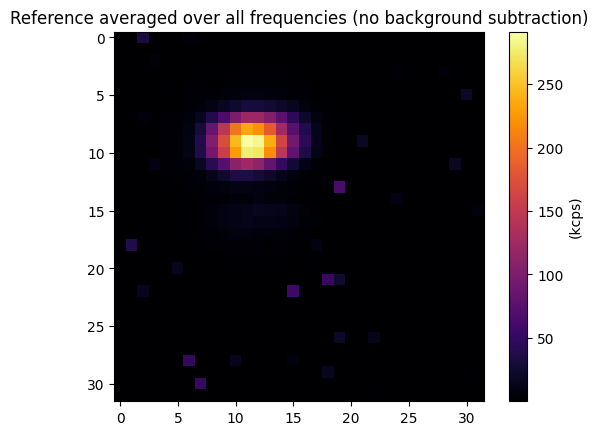

In [88]:
plt.imshow(1e-3*ref_avg_cps.mean(axis =0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all frequencies (no background subtraction)')
plt.show()


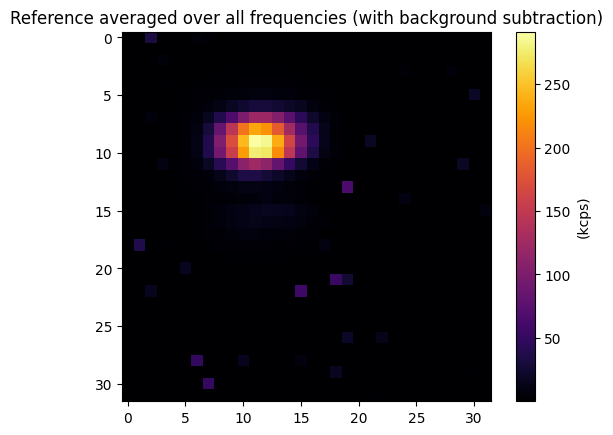

In [89]:
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis =0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all frequencies (with background subtraction)')
plt.show()


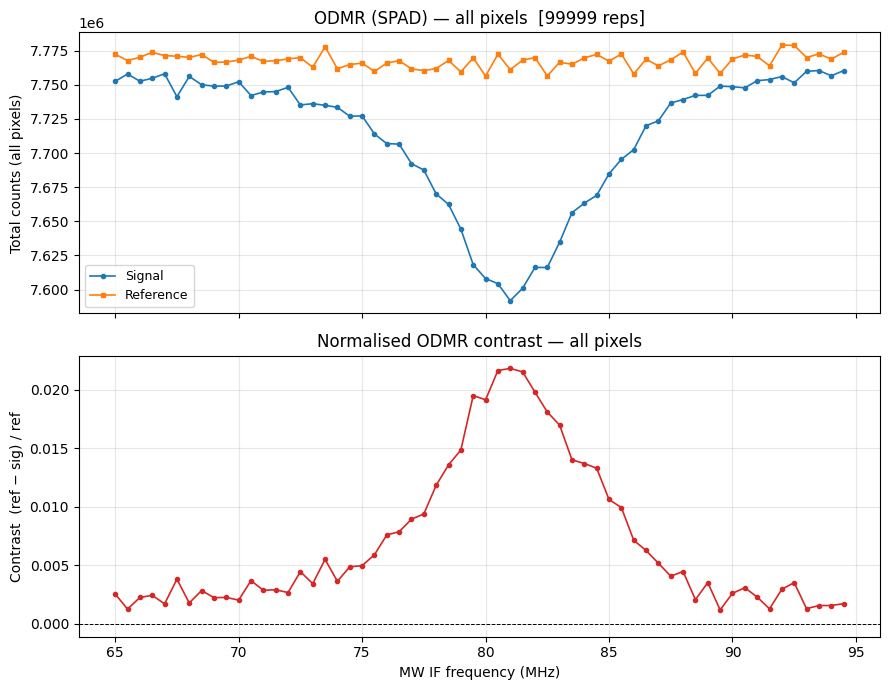

In [90]:
f_mhz = f_mw_hz / 1e6

# Sum all pixels at each frequency — identical to SPAD_ODMR_test
#sig_counts  = sig_avg.sum(axis=(-1, -2))   # (F,)
#ref_counts  = ref_avg.sum(axis=(-1, -2))   # (F,)

sig_counts  = sig_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)
ref_counts  = ref_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_all = np.where(ref_counts != 0, (ref_counts - sig_counts) / ref_counts, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(f_mhz, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(f_mhz, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
axes[0].set_ylabel('Total counts (all pixels)')
axes[0].set_title(f'ODMR (SPAD) — all pixels  [{n_complete_reps} reps]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_mhz, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.7, ls='--')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised ODMR contrast — all pixels')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Array centre (brightest pixel in ref_avg.mean): row=9, col=11


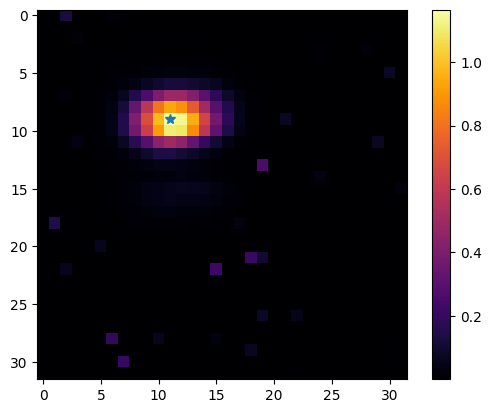

In [91]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
# ref_avg has no ODMR dip, so every frequency contributes equally — more robust than
# using a single signal frame that may be suppressed near resonance.
ref_frame = ref_avg.mean(axis=0)  # (rows, cols) — mean reference over all frequencies
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

plt.imshow(ref_frame, cmap='inferno')
plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)
plt.colorbar()
plt.show()

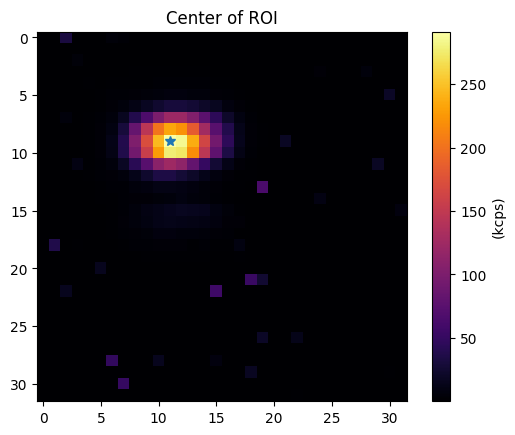

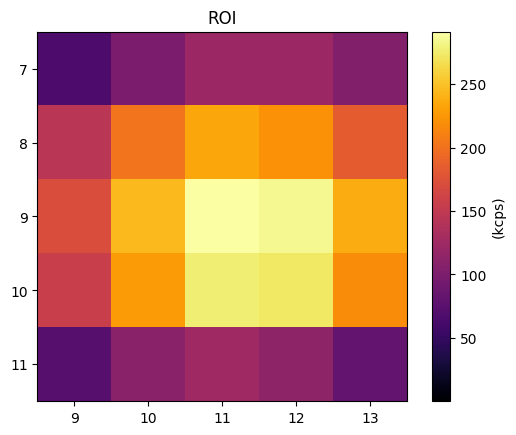

In [92]:
# option: manually set center of ROI 
bright_rc = (9,11)
n = 5 # size of ROI (n x n pixels)

#plot ref image with emitter centre marked
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis=0), cmap='inferno')
plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)
plt.colorbar(label='(kcps)')
plt.title('Center of ROI')
plt.show()

#plot zoom in around emitter array
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis=0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.xlim(bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5)
plt.ylim(bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5)
plt.title('ROI')
plt.show()

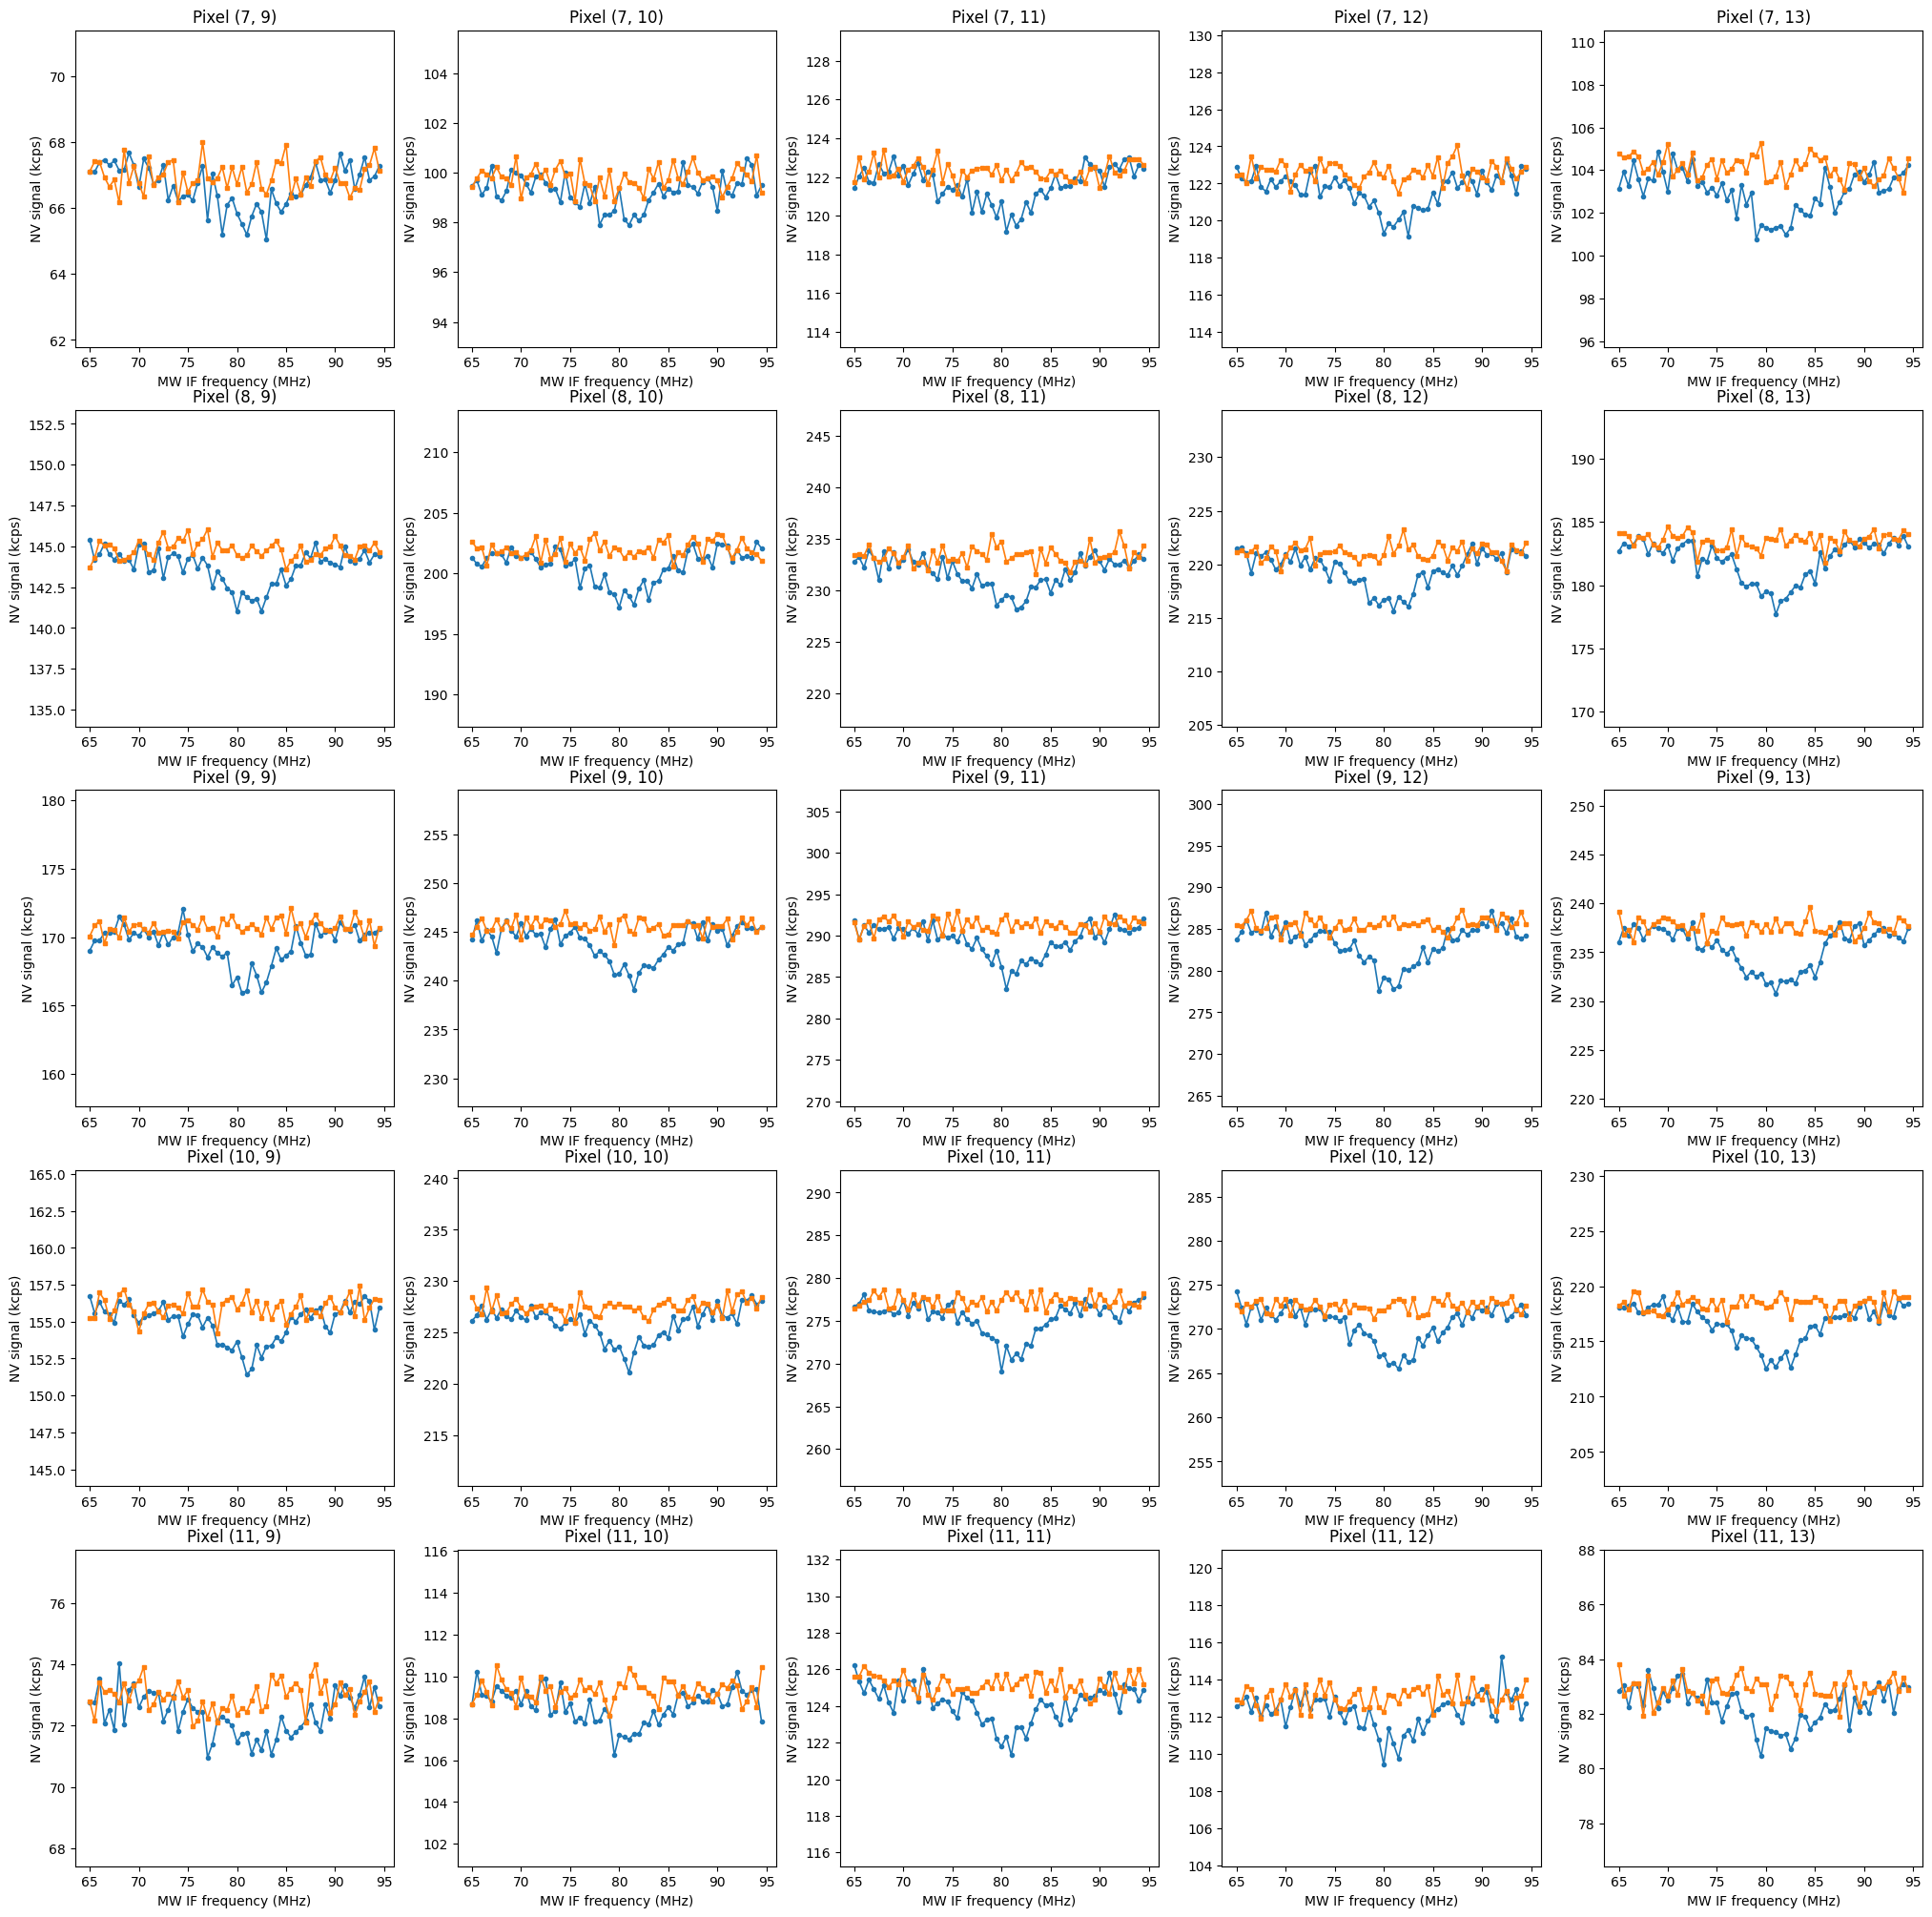

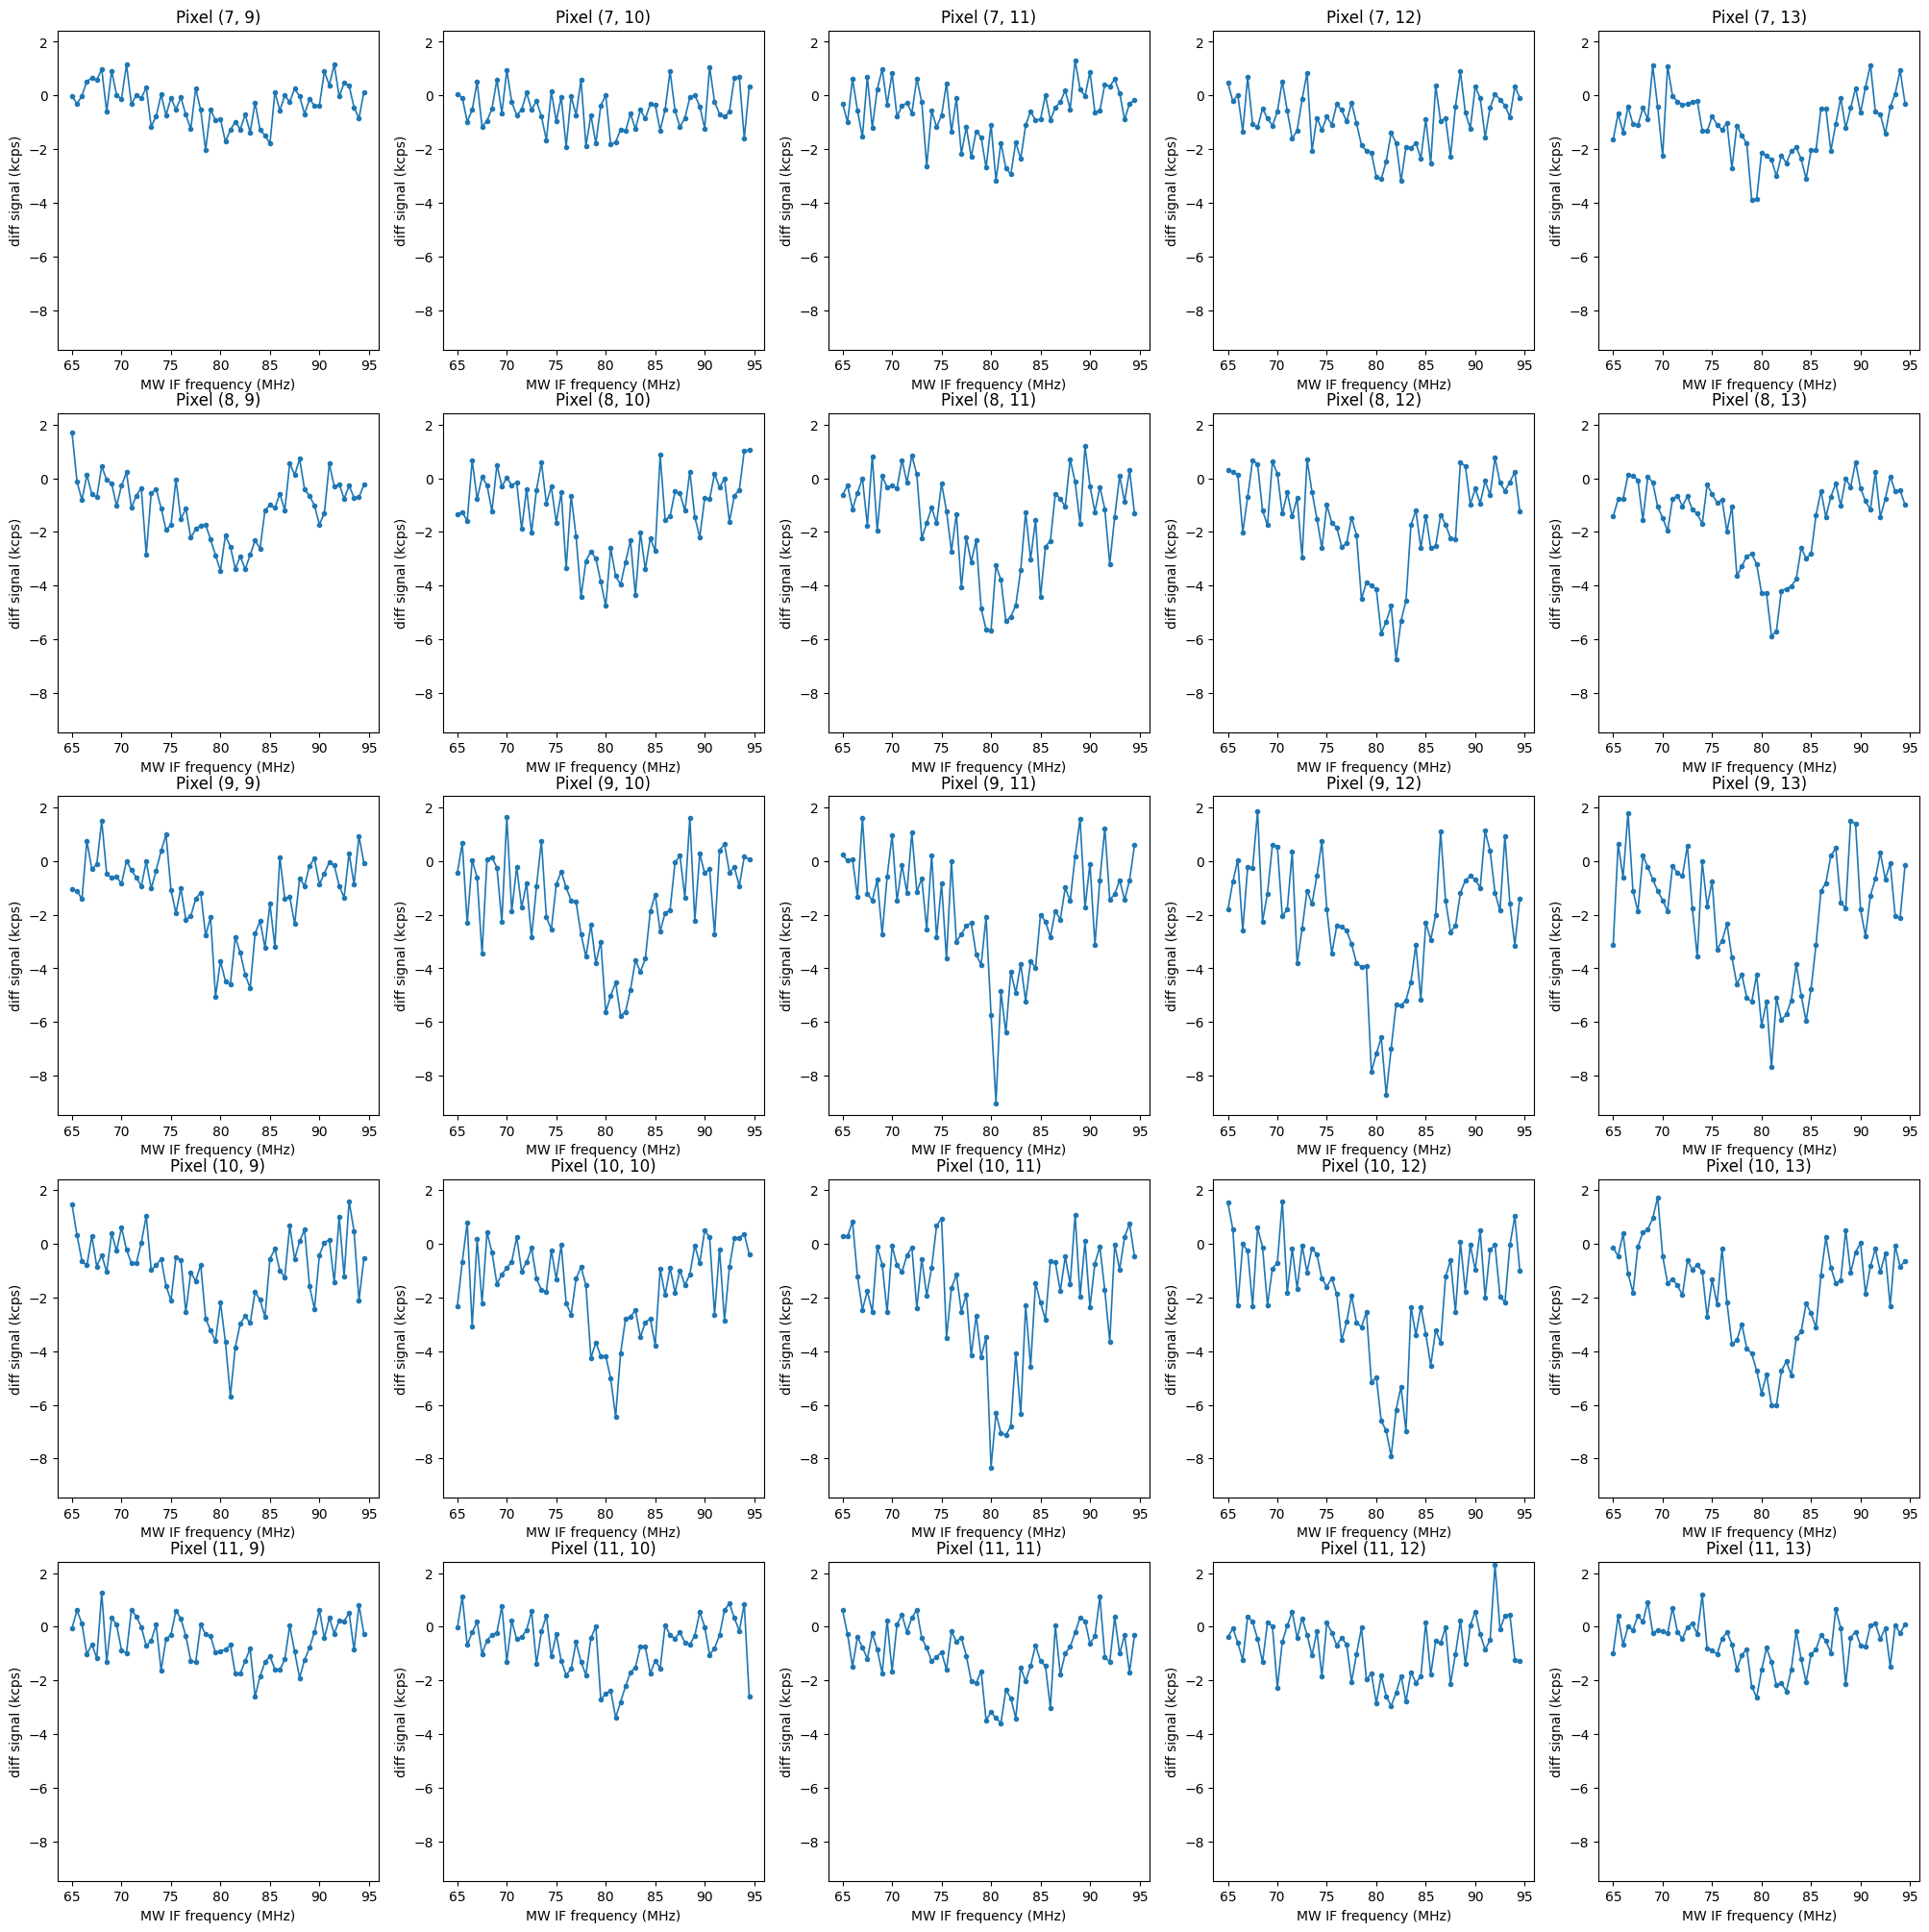

In [93]:
#make nXn grid of plots for pixels in ROI around emitter array center
plt.subplots(n, n, figsize=(5*n, 5*n))

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]

        plt.subplot(n, n, i*n + j + 1)
        plt.plot(f_mhz, sig*1e-3, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(f_mhz, ref*1e-3, 's-', ms=3, lw=1.2, label='Reference')
        plt.ylim(min(sig.min(), ref.min()) * 0.95 *1e-3, max(sig.max(), ref.max()) * 1.05 *1e-3)
        plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('NV signal (kcps)')

plt.subplots(n, n, figsize=(5*n, 5*n))

# Global y-limits across all ROI (sig-ref) traces for consistent second-subplot scaling
global_min = np.inf
global_max = -np.inf
for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        trace = sig - ref
        global_min = min(global_min, trace.min())
        global_max = max(global_max, trace.max())

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]

        plt.subplot(n, n, i*n + j + 1)
        plt.plot(f_mhz, 1e-3*(sig - ref), 'o-', ms=3, lw=1.2, label='Signal')
        if global_min > 0 and global_max > 0:
            plt.ylim(global_min * 0.95 * 1e-3, global_max * 1.05 * 1e-3)
        elif global_min < 0 and global_max < 0:
            plt.ylim(global_min * 1.05 * 1e-3, global_max * 0.95 * 1e-3)
        else:
            plt.ylim(global_min * 1.05 * 1e-3, global_max * 1.05 * 1e-3)
        plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('diff signal (kcps)')

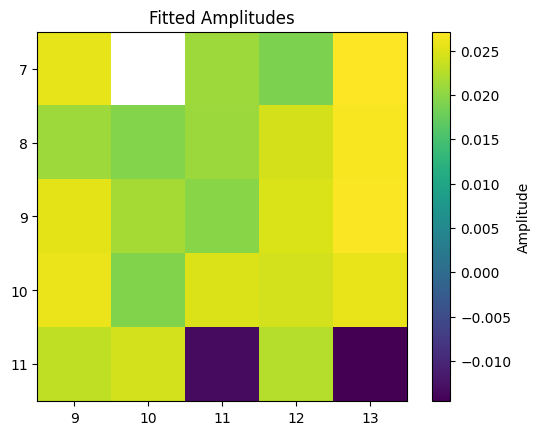

In [94]:
#fit Lorentzian to each pixel's contrast curve to extract amplitude, resonance frequency, and linewidth
from scipy.optimize import curve_fit
def lorentzian(f, f0, gamma, A, C):
    return A * (gamma**2 / ((f - f0)**2 + gamma**2)) + C
f0s = np.zeros((n, n))
gammas = np.zeros((n, n))
amps = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        contrast = np.where(ref != 0, (ref - sig) / ref, 0.0)

        try:
            popt, _ = curve_fit(lorentzian, f_mhz, contrast, p0=[f_mhz[np.argmin(contrast)], 10, contrast.min(), contrast.max()])
            f0s[i, j], gammas[i, j], amps[i, j] = popt[0], popt[1], popt[2]
        except RuntimeError:
            f0s[i, j], gammas[i, j], amps[i, j] = np.nan, np.nan, np.nan

    
# Plot fitted contrast amplitude, resonance frequency, and linewidth for each pixel in the ROI
plt.figure()
plt.imshow(amps, cmap='viridis', extent=[bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5, bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5])
plt.colorbar(label='Amplitude')
plt.title('Fitted Amplitudes')
plt.show()


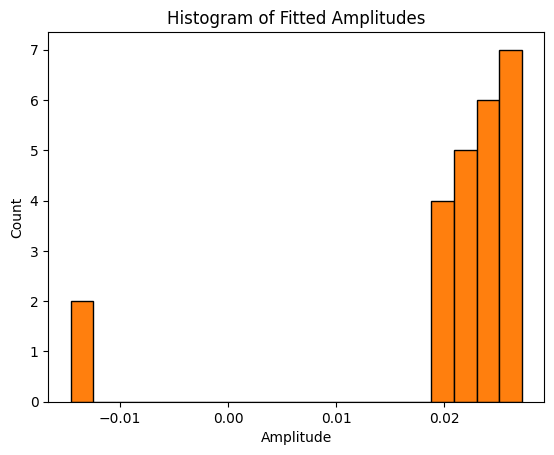

In [95]:
#plot histogram of amplitudes
plt.figure()
plt.hist(amps.flatten(), bins=20, color='C1', edgecolor='k')
plt.xlabel('Amplitude')
plt.ylabel('Count')
plt.title('Histogram of Fitted Amplitudes')
plt.show()